<a href="https://colab.research.google.com/github/sungmin-Jeon/financial_practice-/blob/main/notebooks/Spurious_regression(or_correlation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm

In [2]:
def one_trial(T=120, mu=0.01, sigma=0.08, P0=100, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # monthly log returns
    eps = np.random.normal(0, 1, T)
    R = mu + sigma * eps

    # log price 생성
    logP = np.empty(T + 1)
    logP[0] = np.log(P0)

    for t in range(1, T + 1):
        logP[t] = logP[t-1] + R[t - 1]

    # 회귀용 데이터
    y = R
    x = logP[:-1]
    X = sm.add_constant(x)

    model = sm.OLS(y, X).fit()

    a_hat = model.params[0]
    b_hat = model.params[1]

    return {
        "R": R,
        "logP": logP,
        "a_hat": a_hat,
        "b_hat": b_hat,
        "model": model
    }

In [3]:
result = one_trial(T=120, mu=0.01, sigma=0.08, P0=100, seed=42)

print("a_hat =", result["a_hat"])
print("b_hat =", result["b_hat"])
print(result["model"].summary())

a_hat = 0.19633115136258555
b_hat = -0.041654768394979946
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.829
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.179
Time:                        05:45:33   Log-Likelihood:                 143.55
No. Observations:                 120   AIC:                            -283.1
Df Residuals:                     118   BIC:                            -277.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

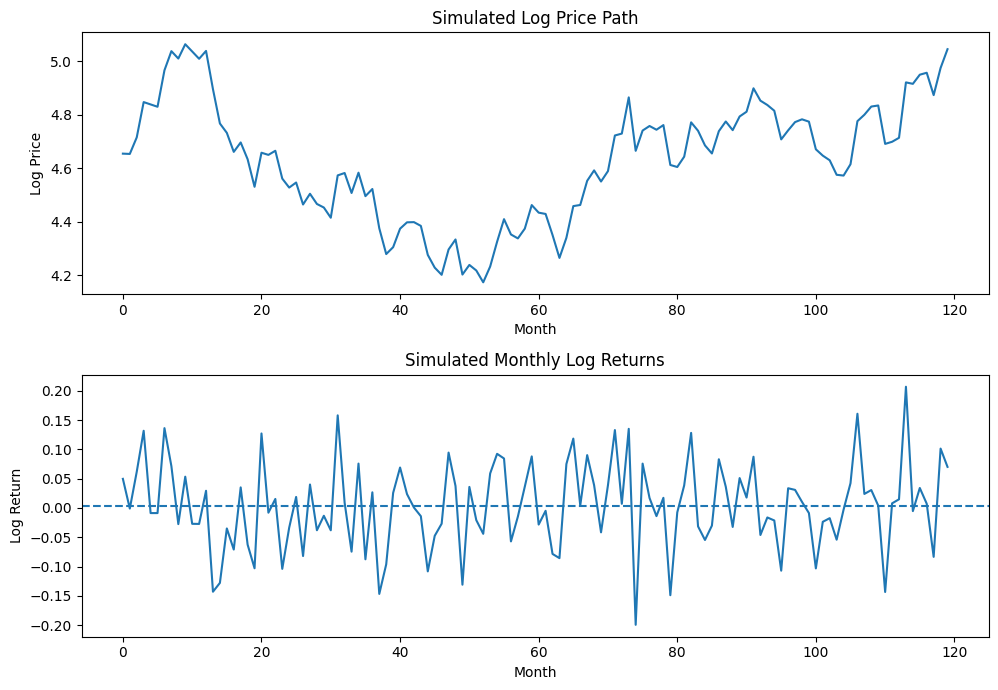

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(logP[1:])
axes[0].set_title("Simulated Log Price Path")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Log Price")

axes[1].plot(R)
axes[1].axhline(R.mean(), linestyle='--')
axes[1].set_title("Simulated Monthly Log Returns")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Log Return")

plt.tight_layout()
plt.show()

In [5]:
# -----------------------------
# 3. Monte Carlo 반복
# -----------------------------
def monte_carlo_experiment(N=100, T=120, mu=0.01, sigma=0.08, P0=100):
    a_list = []
    b_list = []
    t_list = []
    p_list = []

    for i in range(N):
        result = one_trial(T=T, mu=mu, sigma=sigma, P0=P0, seed=None)
        model = result["model"]

        a_list.append(result["a_hat"])
        b_list.append(result["b_hat"])
        t_list.append(model.tvalues[1])
        p_list.append(model.pvalues[1])

    return pd.DataFrame({
        "a_hat": a_list,
        "b_hat": b_list,
        "t_stat_b": t_list,
        "p_value_b": p_list
    })


mc_df = monte_carlo_experiment(N=5000, T=120, mu=0.01, sigma=0.08, P0=100)

mc_df.describe()

,a_hat,b_hat,t_stat_b,p_value_b
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.151157,-0.028082,-1.188678,0.314382
std,0.148303,0.031385,0.978006,0.291437
min,-0.132791,-0.306024,-4.589540,0.000011
25%,0.052289,-0.040353,-1.867212,0.063932
50%,0.115663,-0.019927,-1.229287,0.215091
75%,0.212800,-0.007454,-0.532832,0.515767
max,1.385664,0.030212,2.487764,0.999774


In [20]:
print("평균 a_hat:", mc_df["a_hat"].mean())
print("평균 b_hat:", mc_df["b_hat"].mean())
print("b 유의확률 5% 미만 비율:", (mc_df["p_value_b"] < 0.05).mean())
print("평균 |t-stat|:", mc_df["t_stat_b"].abs().mean())

평균 a_hat: 0.1514441587588559
평균 b_hat: -0.02815675786393752
b 유의확률 5% 미만 비율: 0.218
평균 |t-stat|: 1.3077126918735158


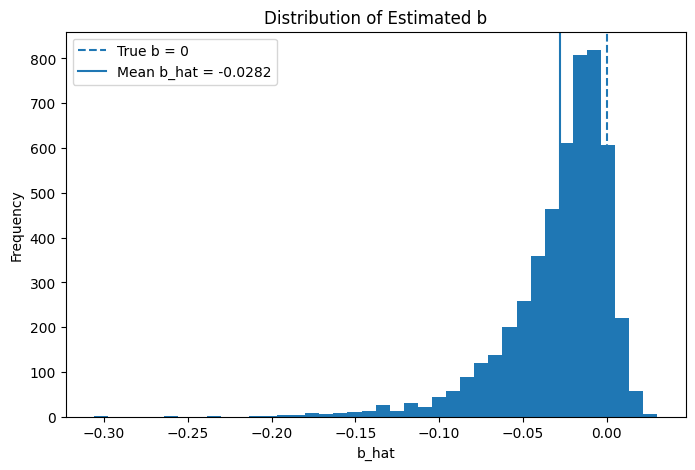

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(mc_df["b_hat"], bins=40)
plt.axvline(0, linestyle='--', label='True b = 0')
plt.axvline(mc_df["b_hat"].mean(), linestyle='-', label=f"Mean b_hat = {mc_df['b_hat'].mean():.4f}")
plt.title("Distribution of Estimated b")
plt.xlabel("b_hat")
plt.ylabel("Frequency")
plt.legend()
plt.show()

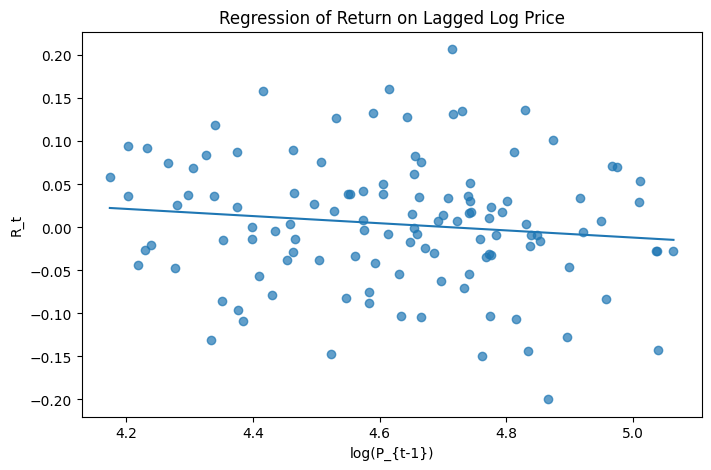

In [22]:
x = result["logP"][:-1]
y = result["R"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("log(P_{t-1})")
plt.ylabel("R_t")
plt.title("Regression of Return on Lagged Log Price")

# 회귀선
b0 = result["model"].params[0]
b1 = result["model"].params[1]
x_line = np.linspace(x.min(), x.max(), 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line)

plt.show()